In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import duckdb 
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flight-price-prediction/business.csv
/kaggle/input/flight-price-prediction/economy.csv
/kaggle/input/flight-price-prediction/Clean_Dataset.csv


# EDA using pandas

In [2]:
Clean_Dataset_df = pd.read_csv("/kaggle/input/flight-price-prediction/Clean_Dataset.csv")
Clean_Dataset_df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
Clean_Dataset_df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [4]:
Clean_Dataset_df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
Clean_Dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [6]:
Clean_Dataset_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,NaN,NaN,NaN,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0


In [7]:
Clean_Dataset_df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


## Discovery #1: Airline
`Vistara`, `Indigo` and `Air_India` are the airlines with top 3 flight frequency. 


In [8]:
Clean_Dataset_df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [9]:
Clean_Dataset_df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

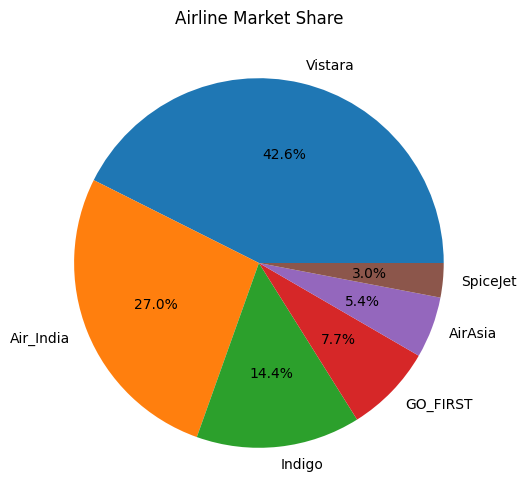

In [10]:
Clean_Dataset_df["airline"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Airline Market Share")
plt.ylabel("")
plt.show()

## Discovery #2: Source City
`Delhi` and `Mumbai` is showing similar frequency (Top 1 and Top 2) of Source City, followed by `Bangalore` as the Top 3 source city in this dataset.

In [11]:
 Clean_Dataset_df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

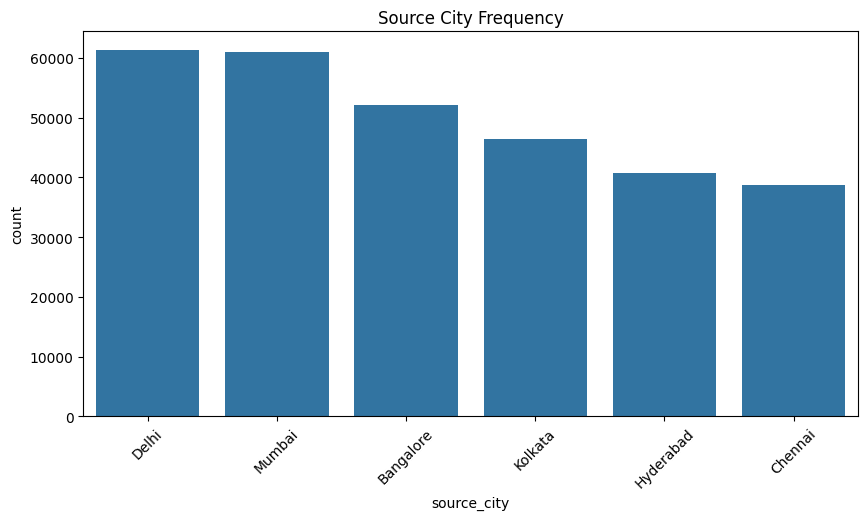

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=Clean_Dataset_df, x="source_city")
plt.xticks(rotation=45)
plt.title("Source City Frequency")
plt.show()

## Discovery #3: Departure Time
Most customers prefer to depart to their destination during `Morning` and `Early Morning` session, followed by `Evening` timeslot.

In [13]:
 Clean_Dataset_df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

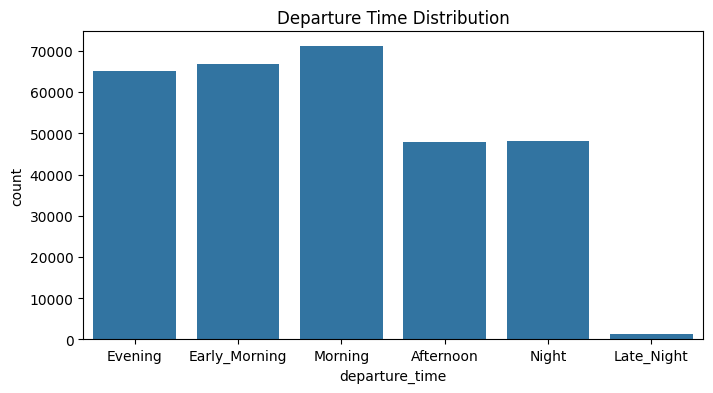

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="departure_time")
plt.title("Departure Time Distribution")
plt.show()

## Discovery #4: Stops
Most flights has at least 1 stop.

In [15]:
 Clean_Dataset_df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [16]:
 Clean_Dataset_df['stops'].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

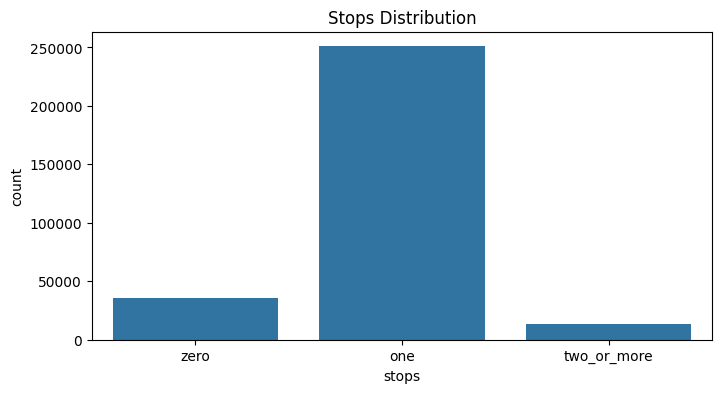

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="stops")
plt.title("Stops Distribution")
plt.show()

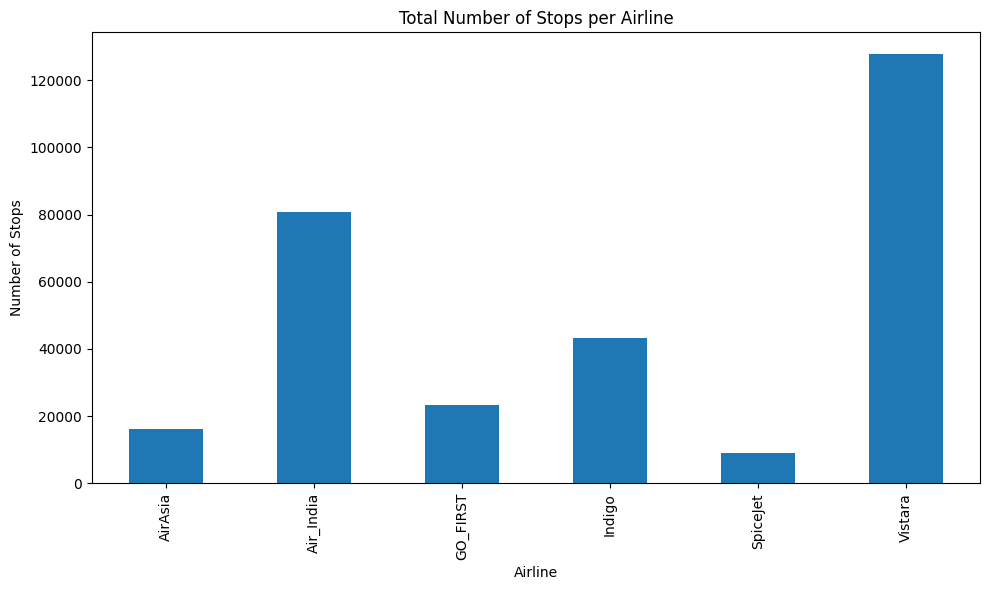

In [18]:
import matplotlib.pyplot as plt
airline_price = Clean_Dataset_df.groupby('airline')['stops'].count()

plt.figure(figsize=(10, 6))
airline_price.plot(kind='bar')
plt.xlabel('Airline')
plt.ylabel('Number of Stops')
plt.title('Total Number of Stops per Airline')
plt.tight_layout()
plt.show()

## Discovery #5: Arrival Time
Most customers arrive at their destination during `Night` session, followed by `Evening` session and `Morning` session.

In [19]:
Clean_Dataset_df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [20]:
Clean_Dataset_df['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

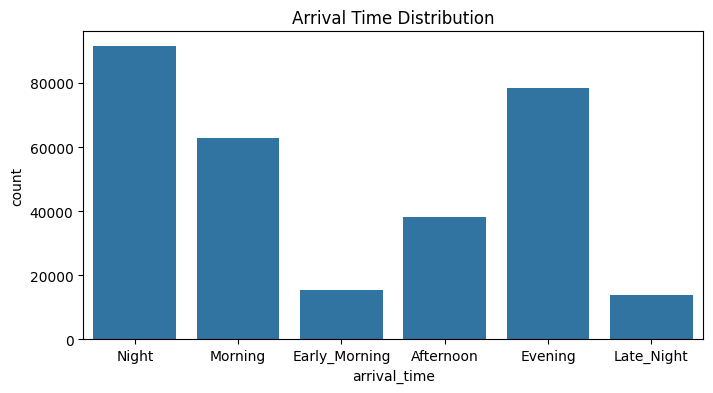

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="arrival_time")
plt.title("Arrival Time Distribution")
plt.show()

## Discovery #6: Destination City
`Delhi` and `Mumbai` is showing similar frequency (Top 1 and Top 2) of Destination City, followed by `Bangalore` as the Top 3 source city in this dataset.

In [22]:
 Clean_Dataset_df['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

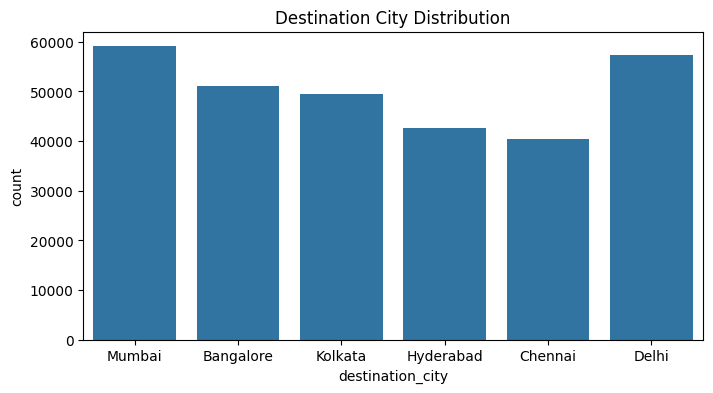

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="destination_city")
plt.title("Destination City Distribution")
plt.show()

## Discovery #7: Class
There are two classes of flight services available in this dataset. 

In [24]:
Clean_Dataset_df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

## Discovery #8: duration, days_left, price

In [25]:
Clean_Dataset_df['duration'].value_counts()

duration
2.17     4242
2.25     4036
2.75     2879
2.08     2755
2.83     2323
         ... 
47.08       1
41.58       1
37.17       1
44.50       1
41.50       1
Name: count, Length: 476, dtype: int64

In [26]:
conditions = [
    (Clean_Dataset_df["duration"] > 0) & (Clean_Dataset_df["duration"] <= 3),
    (Clean_Dataset_df["duration"] > 3) & (Clean_Dataset_df["duration"] <= 6),
    (Clean_Dataset_df["duration"] > 6) & (Clean_Dataset_df["duration"] <= 12),
    (Clean_Dataset_df["duration"] > 12)
]

choices = [
    "short-haul-flight",
    "medium-haul-flight",
    "long-haul-flight",
    "ultra-long-haul-flight"
]

Clean_Dataset_df["flight_length"] = np.select(conditions, choices, default="Unknown")

In [27]:
Clean_Dataset_df["flight_length"].value_counts()

flight_length
ultra-long-haul-flight    136225
long-haul-flight          102751
short-haul-flight          35811
medium-haul-flight         25366
Name: count, dtype: int64

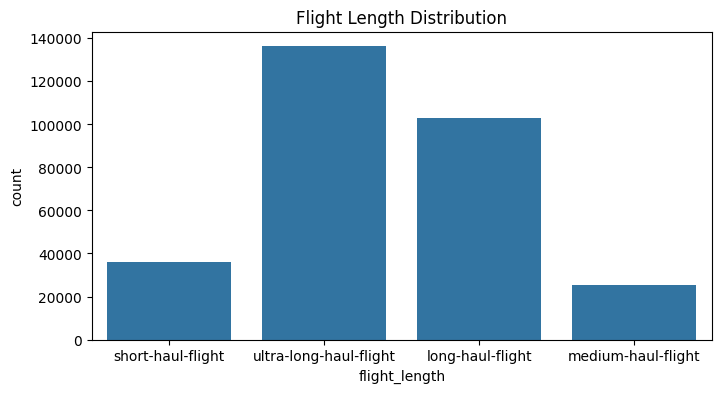

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="flight_length")
plt.title("Flight Length Distribution")
plt.show()

In [29]:
# Correlation
corr = Clean_Dataset_df['duration'].corr(Clean_Dataset_df['price'])
print(f"Correlation Coefficient: {corr:.3f}")

Correlation Coefficient: 0.204


In [30]:
# Correlation
corr = Clean_Dataset_df['days_left'].corr(Clean_Dataset_df['price'])
print(f"Correlation Coefficient: {corr:.3f}")

Correlation Coefficient: -0.092


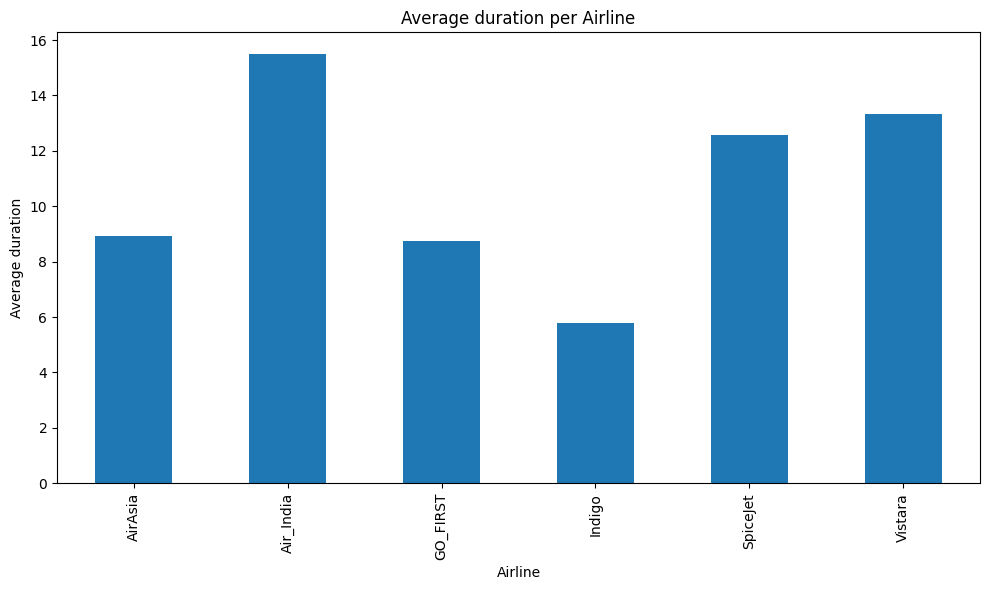

In [31]:
import matplotlib.pyplot as plt
airline_price = Clean_Dataset_df.groupby('airline')['duration'].mean()

plt.figure(figsize=(10, 6))
airline_price.plot(kind='bar')
plt.xlabel('Airline')
plt.ylabel('Average duration')
plt.title('Average duration per Airline')
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

# Assuming `test` is already a pandas DataFrame
df = Clean_Dataset_df.pivot_table(
    index="airline",        # GROUP BY airline
    columns="flight_length",# PIVOT on flight_length
    values="duration",      # USING avg(duration)
    aggfunc="mean"          # avg()
).reset_index()

# Sort airline descending
df = df.sort_values("airline", ascending=False)

print(df)

flight_length    airline  long-haul-flight  medium-haul-flight  \
5                Vistara          9.313952            5.343781   
4               SpiceJet          9.175176            4.847746   
3                 Indigo          8.042382            5.034381   
2               GO_FIRST          8.973210            5.222151   
1              Air_India          9.299615            5.005156   
0                AirAsia          9.381121            5.190731   

flight_length  short-haul-flight  ultra-long-haul-flight  
5                       2.237969               18.229592  
4                       2.326954               20.481229  
3                       2.077055               13.885367  
2                       2.137778               14.227539  
1                       2.307718               19.645685  
0                       2.074680               14.217223  


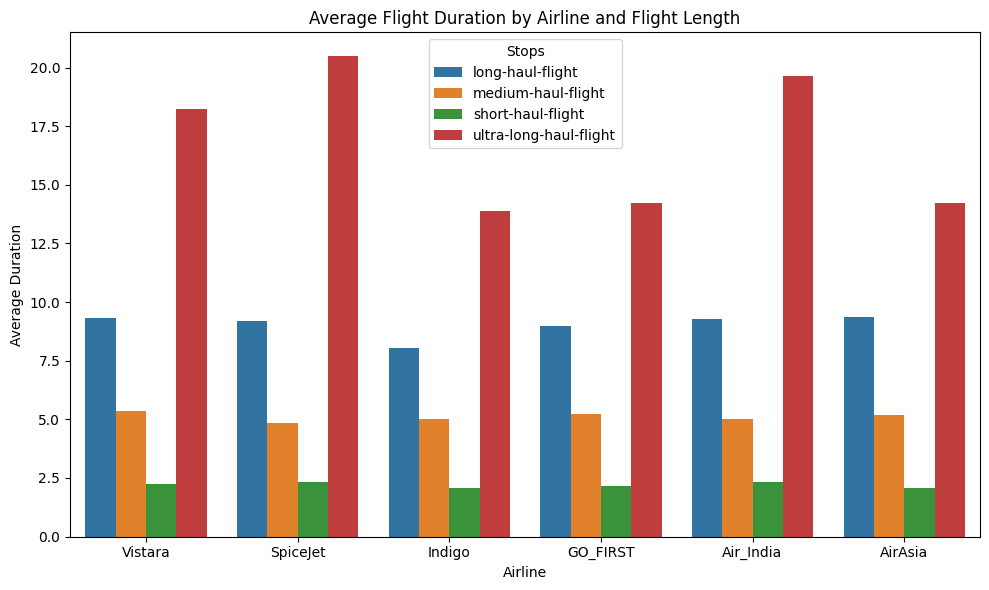

In [33]:
# Melt the pivoted table for easier plotting
df_melted = df.melt(id_vars="airline", var_name="flight_length", value_name="avg_duration")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="airline", y="avg_duration", hue="flight_length")

plt.title("Average Flight Duration by Airline and Flight Length")
plt.xlabel("Airline")
plt.ylabel("Average Duration")
plt.legend(title="Stops")
plt.tight_layout()
plt.show()

# EDA (Exploratory Data Analysis) using DuckDB

In [34]:
conn = duckdb.connect(database=':memory:', read_only=False)

No permanent table created in DuckDB, memory is used for EDA instead. 

In [35]:
conn.sql('show tables')

┌─────────┐
│  name   │
│ varchar │
├─────────┤
│ 0 rows  │
└─────────┘

In [36]:
duckdb.sql("""
CREATE TABLE test AS SELECT * FROM Clean_Dataset_df
""")

In [37]:
duckdb.sql("""
SELECT * FROM test;
""").df()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,flight_length
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,short-haul-flight
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,short-haul-flight
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,short-haul-flight
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,short-haul-flight
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,short-haul-flight
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,long-haul-flight
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,long-haul-flight
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,ultra-long-haul-flight
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,long-haul-flight


## Discovery #9: PIVOT - Stops
- The average flight duration of airlines tends to increase as number of stops increases
- The average flight duration for path with `zero` stops ranges from 2.075 to 2.33 hours
- As number of stop increases, travel time increases at least by 3 times. 
- `SpiceJet` doesn't offer flight services that comes with `two_or_more` number of stops

In [38]:
# Run your DuckDB pivot query
df = duckdb.sql("""
    PIVOT test
    ON stops
    USING avg(duration)
    GROUP BY airline
    ORDER BY airline DESC;
""").df()

print(df)

     airline        one  two_or_more      zero
0    Vistara  14.270238    14.706963  2.237969
1   SpiceJet  16.432874          NaN  2.330378
2     Indigo   7.033982     9.868808  2.084934
3   GO_FIRST   9.790916    11.444198  2.137778
4  Air_India  16.437990    20.733691  2.320648
5    AirAsia   9.969373    11.159239  2.074680


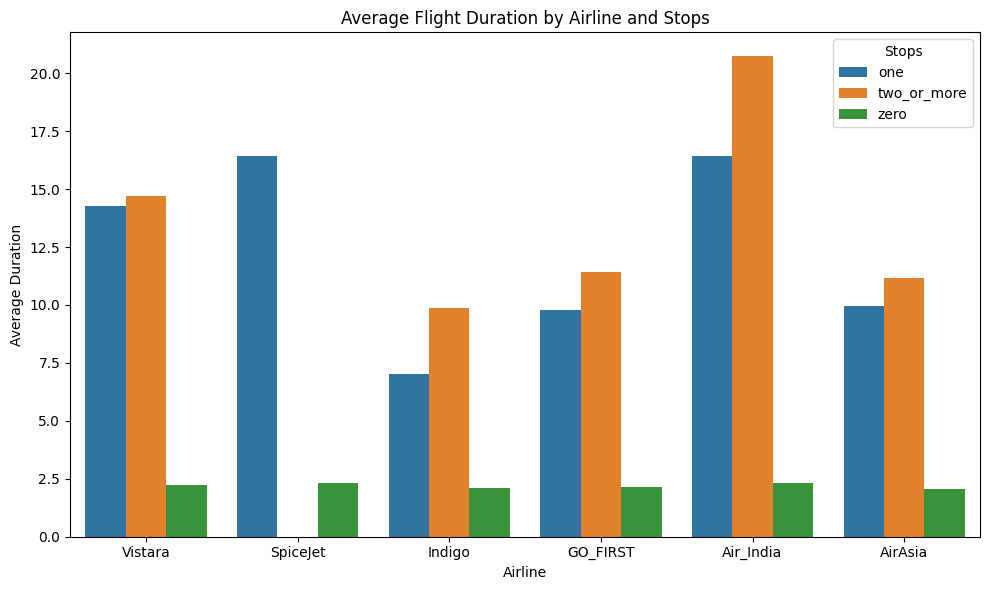

In [39]:
# Melt the pivoted table for easier plotting
df_melted = df.melt(id_vars="airline", var_name="stops", value_name="avg_duration")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="airline", y="avg_duration", hue="stops")

plt.title("Average Flight Duration by Airline and Stops")
plt.xlabel("Airline")
plt.ylabel("Average Duration")
plt.legend(title="Stops")
plt.tight_layout()
plt.show()


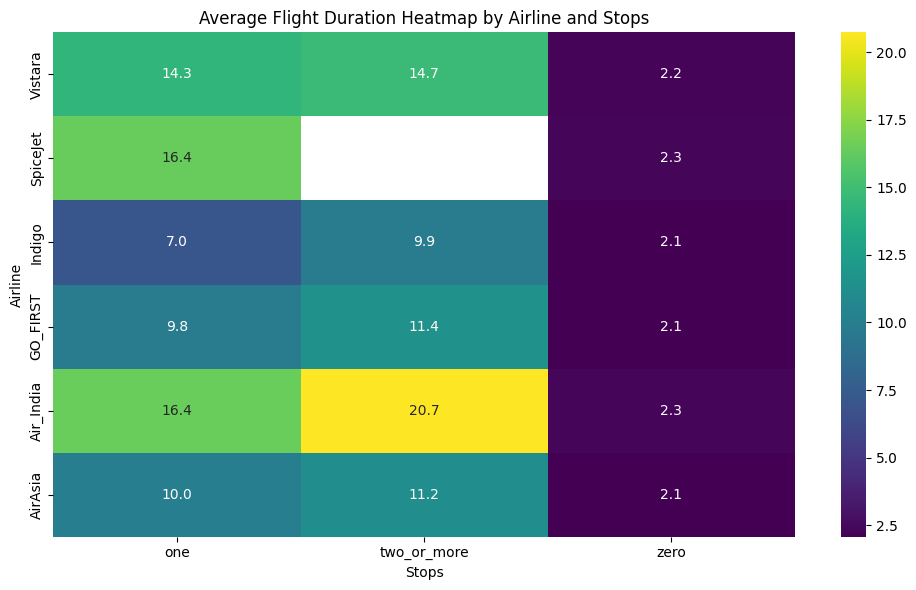

In [40]:
# Set airline as index for heatmap
df_indexed = df.set_index("airline")

plt.figure(figsize=(10, 6))
sns.heatmap(df_indexed, annot=True, cmap="viridis", fmt=".1f")

plt.title("Average Flight Duration Heatmap by Airline and Stops")
plt.xlabel("Stops")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


## Discovery #10: PIVOT - Class

- Only `Vistara` and `Air_India` offers business class travel package to their customers.
- In general, lesser travel time is required for `Business` class to complete their flight services.

In [41]:
df = duckdb.sql("""
PIVOT test
ON class
USING avg(duration)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline   Business    Economy
0    Vistara  13.198963  13.441626
1   SpiceJet        NaN  12.579767
2     Indigo        NaN   5.795197
3   GO_FIRST        NaN   8.755380
4  Air_India  14.634917  16.100119
5    AirAsia        NaN   8.941714


In [42]:
duckdb.sql("""
SELECT airline, COUNT(class) AS Number_of_Flights, AVG(duration) AS avg_duration
FROM test 
WHERE class = 'Business'
GROUP BY airline;
""").df()

,airline,Number_of_Flights,avg_duration
0,Vistara,60589,13.198963
1,Air_India,32898,14.634917


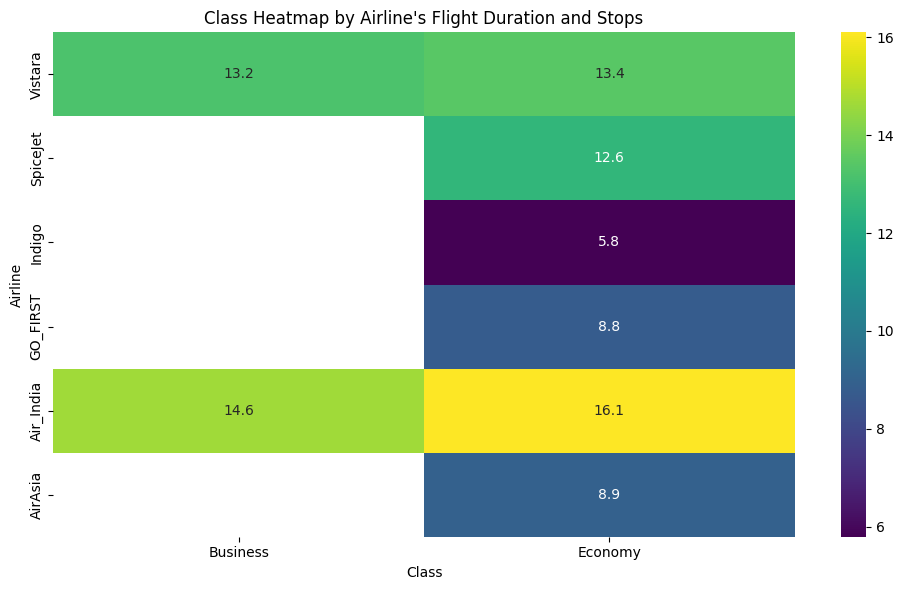

In [43]:
# Set airline as index for heatmap
df_indexed = df.set_index("airline")

plt.figure(figsize=(10, 6))
sns.heatmap(df_indexed, annot=True, cmap="viridis", fmt=".1f")

plt.title("Class Heatmap by Airline's Flight Duration and Stops")
plt.xlabel("Class")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


## Discovery #11: PIVOT - Source City to Destination City
Unlike other airplane service providers, `SpiceJet` airline is yet to offer flight travel services between some part of India. <br>
Example: Mumbai_to_Hyderabad, Hyderabad_to_Bangalore, and Hyderabad_to_Mumbai 

In [44]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Mumbai')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline  Mumbai_to_Bangalore  Mumbai_to_Chennai  Mumbai_to_Delhi  \
0    Vistara               11.692             13.743            9.773   
1   SpiceJet               14.940              5.047            6.601   
2     Indigo                5.175              5.365            4.390   
3   GO_FIRST                8.501              4.247            6.312   
4  Air_India               16.196             16.199           13.274   
5    AirAsia                9.201              9.593            9.152   

   Mumbai_to_Hyderabad  Mumbai_to_Kolkata  
0               13.214             13.267  
1                  NaN             16.831  
2                3.716              5.881  
3               10.230              9.998  
4               16.499             15.825  
5               11.107              9.926  


In [45]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head()


,Mumbai_to_Bangalore,Mumbai_to_Chennai,Mumbai_to_Delhi,Mumbai_to_Hyderabad,Mumbai_to_Kolkata
airline,,,,,
Vistara,11.692,13.743,9.773,13.214,13.267
SpiceJet,14.940,5.047,6.601,0.000,16.831
Indigo,5.175,5.365,4.390,3.716,5.881
GO_FIRST,8.501,4.247,6.312,10.230,9.998
Air_India,16.196,16.199,13.274,16.499,15.825


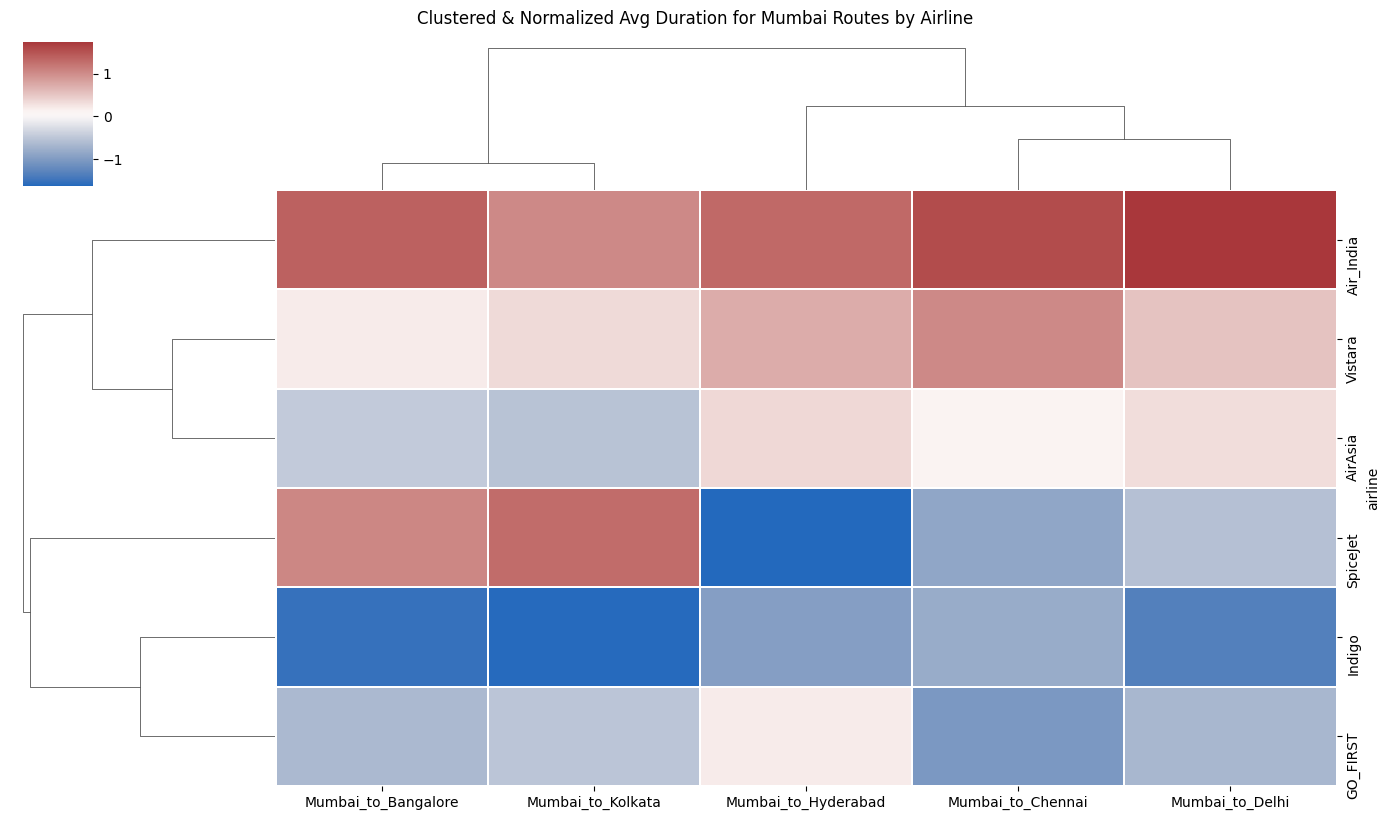

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pivot_norm = pd.DataFrame(
    scaler.fit_transform(pivot),
    index=pivot.index,
    columns=pivot.columns
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    pivot_norm,
    cmap="vlag",
    linewidths=0.3,
    figsize=(14, 8)
)

plt.suptitle("Clustered & Normalized Avg Duration for Mumbai Routes by Airline", y=1.02)
plt.show()


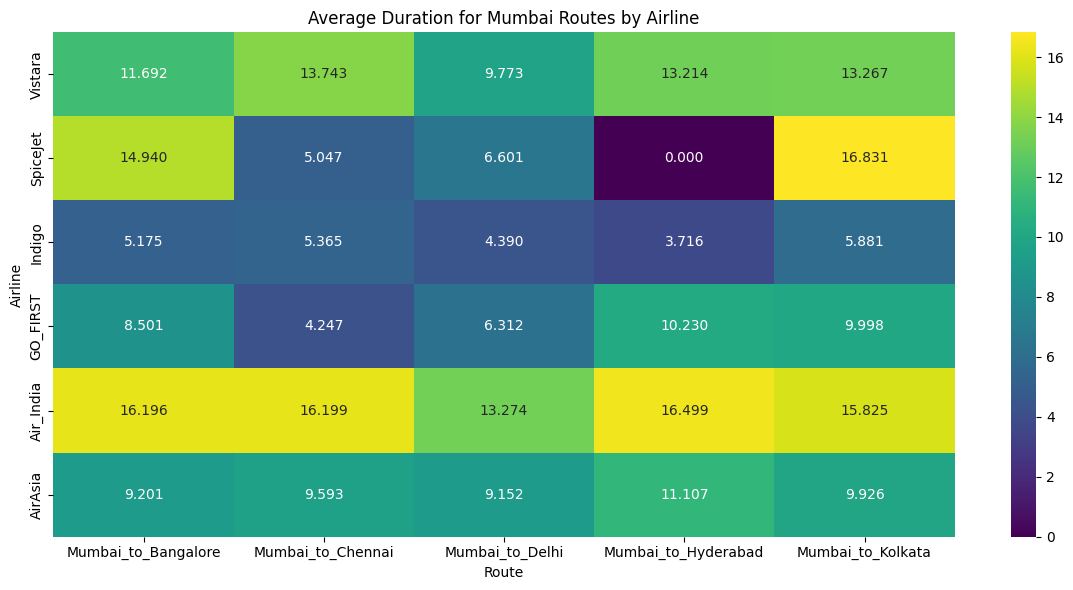

In [47]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Mumbai Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


In [48]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Delhi')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline  Delhi_to_Bangalore  Delhi_to_Chennai  Delhi_to_Hyderabad  \
0    Vistara              10.131            12.556              13.397   
1   SpiceJet              13.066            15.147               5.404   
2     Indigo               6.572             6.672               5.593   
3   GO_FIRST               7.170             9.442               7.695   
4  Air_India              15.081            16.745              15.826   
5    AirAsia               8.461            11.102               9.192   

   Delhi_to_Kolkata  Delhi_to_Mumbai  
0            14.766           10.323  
1            11.880            8.172  
2             5.124            5.005  
3            10.378            6.598  
4            16.171           13.663  
5             9.523           10.319  


In [49]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head()

,Delhi_to_Bangalore,Delhi_to_Chennai,Delhi_to_Hyderabad,Delhi_to_Kolkata,Delhi_to_Mumbai
airline,,,,,
Vistara,10.131,12.556,13.397,14.766,10.323
SpiceJet,13.066,15.147,5.404,11.880,8.172
Indigo,6.572,6.672,5.593,5.124,5.005
GO_FIRST,7.170,9.442,7.695,10.378,6.598
Air_India,15.081,16.745,15.826,16.171,13.663


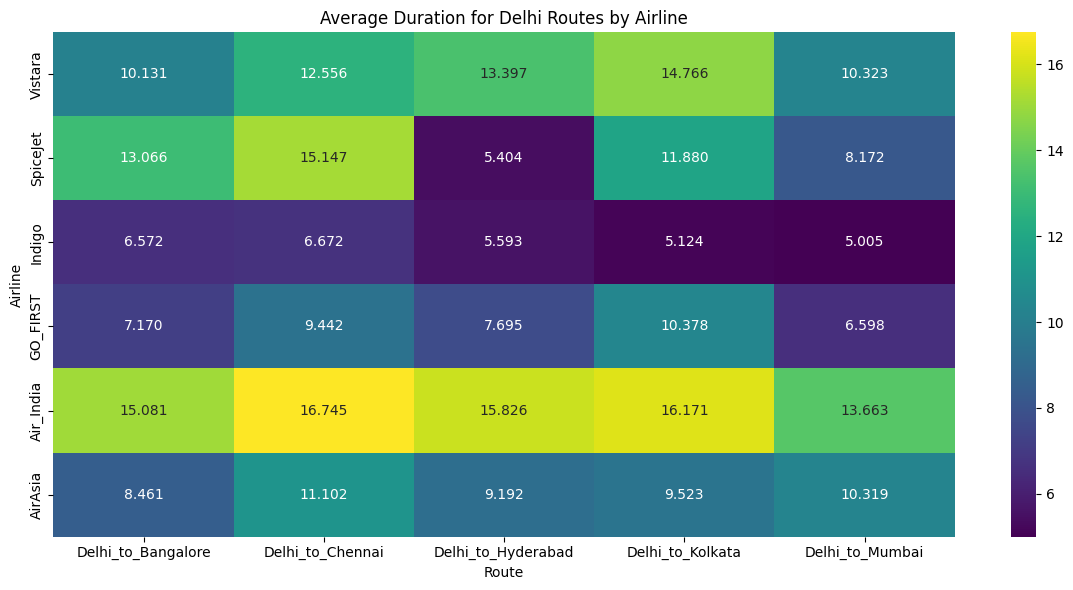

In [50]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Delhi Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


In [51]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Bangalore')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline  Bangalore_to_Chennai  Bangalore_to_Delhi  \
0    Vistara                15.437              10.177   
1   SpiceJet                 1.080              13.185   
2     Indigo                 1.039               6.099   
3   GO_FIRST                10.518               7.480   
4  Air_India                17.029              13.021   
5    AirAsia                 1.040               8.082   

   Bangalore_to_Hyderabad  Bangalore_to_Kolkata  Bangalore_to_Mumbai  
0                  16.281                15.493               11.016  
1                   1.046                 8.894               13.221  
2                   5.011                 6.890                5.111  
3                   9.377                10.552                9.776  
4                  17.227                16.938               14.584  
5                   3.618                 7.557                8.316  


In [52]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head(6)

,Bangalore_to_Chennai,Bangalore_to_Delhi,Bangalore_to_Hyderabad,Bangalore_to_Kolkata,Bangalore_to_Mumbai
airline,,,,,
Vistara,15.437,10.177,16.281,15.493,11.016
SpiceJet,1.080,13.185,1.046,8.894,13.221
Indigo,1.039,6.099,5.011,6.890,5.111
GO_FIRST,10.518,7.480,9.377,10.552,9.776
Air_India,17.029,13.021,17.227,16.938,14.584
AirAsia,1.040,8.082,3.618,7.557,8.316


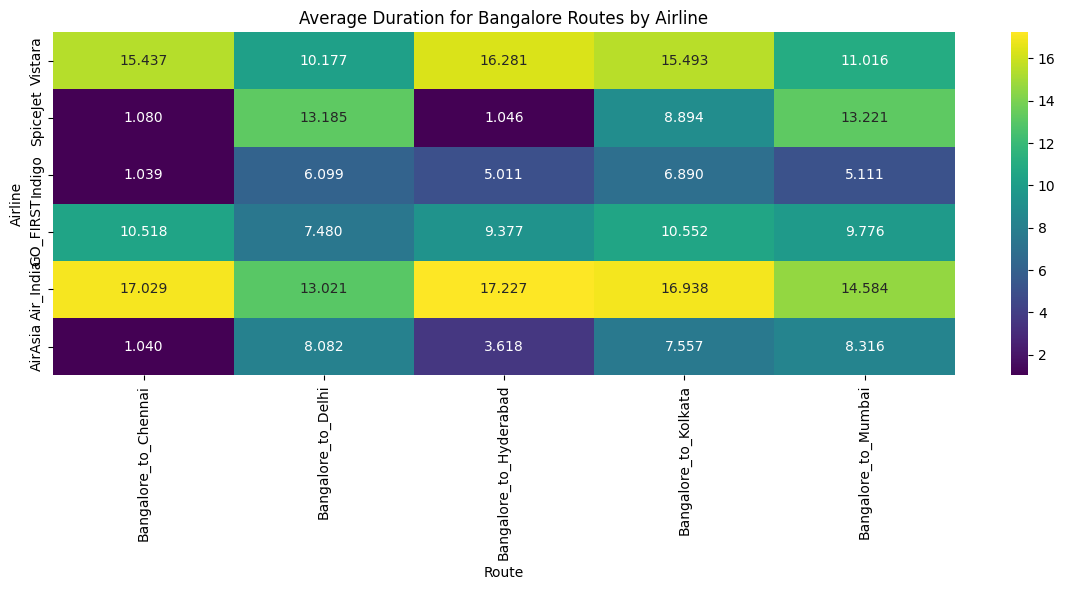

In [53]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Bangalore Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


In [54]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Chennai')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

df.head()

,airline,Chennai_to_Bangalore,Chennai_to_Delhi,Chennai_to_Hyderabad,Chennai_to_Kolkata,Chennai_to_Mumbai
0,Vistara,14.631,11.707,16.568,17.568,12.228
1,SpiceJet,1.330,15.766,7.028,9.953,7.273
2,Indigo,2.785,6.530,5.314,7.185,6.056
3,GO_FIRST,9.101,10.119,1.384,9.932,6.082
4,Air_India,17.329,12.371,14.652,17.867,16.839


In [55]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head(6)

,Chennai_to_Bangalore,Chennai_to_Delhi,Chennai_to_Hyderabad,Chennai_to_Kolkata,Chennai_to_Mumbai
airline,,,,,
Vistara,14.631,11.707,16.568,17.568,12.228
SpiceJet,1.330,15.766,7.028,9.953,7.273
Indigo,2.785,6.530,5.314,7.185,6.056
GO_FIRST,9.101,10.119,1.384,9.932,6.082
Air_India,17.329,12.371,14.652,17.867,16.839
AirAsia,1.175,11.963,6.802,6.311,8.745


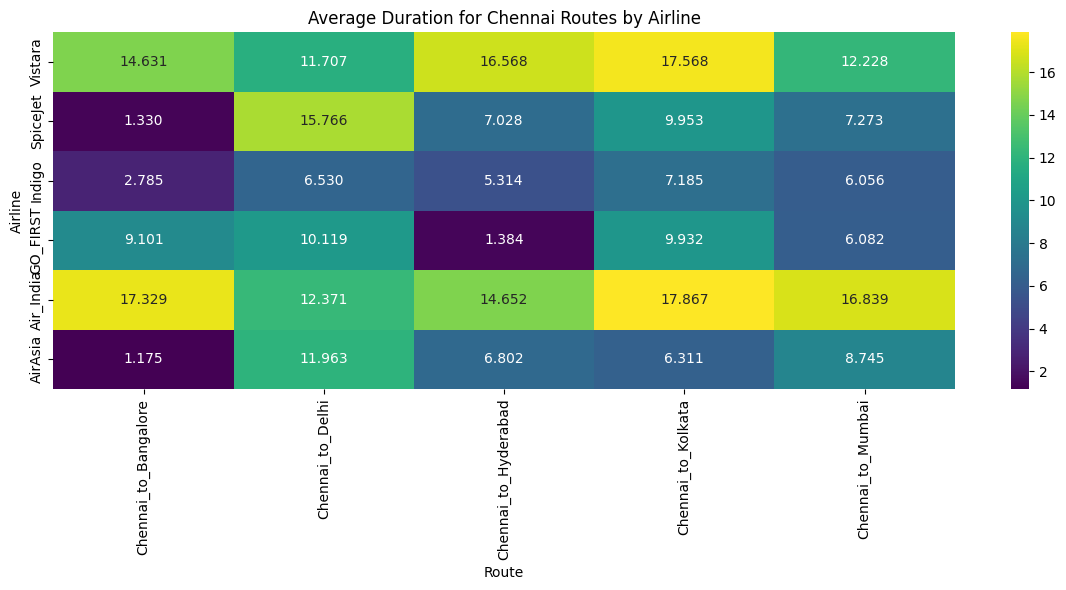

In [56]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Chennai Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

In [57]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Kolkata')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline  Kolkata_to_Bangalore  Kolkata_to_Chennai  Kolkata_to_Delhi  \
0    Vistara                16.170              17.605            12.799   
1   SpiceJet                12.340              11.375            12.366   
2     Indigo                 7.670               7.275             5.663   
3   GO_FIRST                 9.175              11.614             9.721   
4  Air_India                17.169              16.752            14.841   
5    AirAsia                 9.472               6.788            10.749   

   Kolkata_to_Hyderabad  Kolkata_to_Mumbai  
0                16.879             13.078  
1                10.463             16.178  
2                 6.377              6.910  
3                 8.642              9.648  
4                16.898             15.502  
5                 9.231             11.204  


In [58]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head(6)

,Kolkata_to_Bangalore,Kolkata_to_Chennai,Kolkata_to_Delhi,Kolkata_to_Hyderabad,Kolkata_to_Mumbai
airline,,,,,
Vistara,16.170,17.605,12.799,16.879,13.078
SpiceJet,12.340,11.375,12.366,10.463,16.178
Indigo,7.670,7.275,5.663,6.377,6.910
GO_FIRST,9.175,11.614,9.721,8.642,9.648
Air_India,17.169,16.752,14.841,16.898,15.502
AirAsia,9.472,6.788,10.749,9.231,11.204


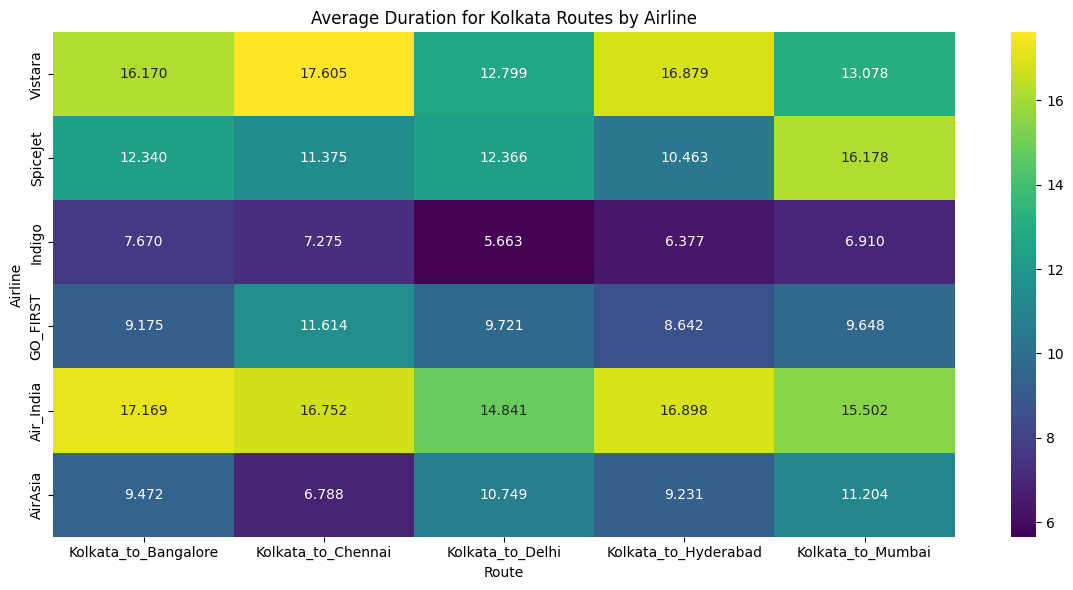

In [59]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Kolkata Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

In [60]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Hyderabad')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").df()

df

,airline,Hyderabad_to_Bangalore,Hyderabad_to_Chennai,Hyderabad_to_Delhi,Hyderabad_to_Kolkata,Hyderabad_to_Mumbai
0,Vistara,14.117,16.043,11.473,16.217,11.854
1,SpiceJet,NaN,1.250,12.025,12.593,NaN
2,Indigo,4.733,5.384,5.958,6.028,4.514
3,GO_FIRST,8.813,1.422,7.781,9.001,9.812
4,Air_India,13.812,15.828,13.193,17.163,15.109
5,AirAsia,5.570,8.316,9.424,7.958,9.408


In [61]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head(6)

,Hyderabad_to_Bangalore,Hyderabad_to_Chennai,Hyderabad_to_Delhi,Hyderabad_to_Kolkata,Hyderabad_to_Mumbai
airline,,,,,
Vistara,14.117,16.043,11.473,16.217,11.854
SpiceJet,0.000,1.250,12.025,12.593,0.000
Indigo,4.733,5.384,5.958,6.028,4.514
GO_FIRST,8.813,1.422,7.781,9.001,9.812
Air_India,13.812,15.828,13.193,17.163,15.109
AirAsia,5.570,8.316,9.424,7.958,9.408


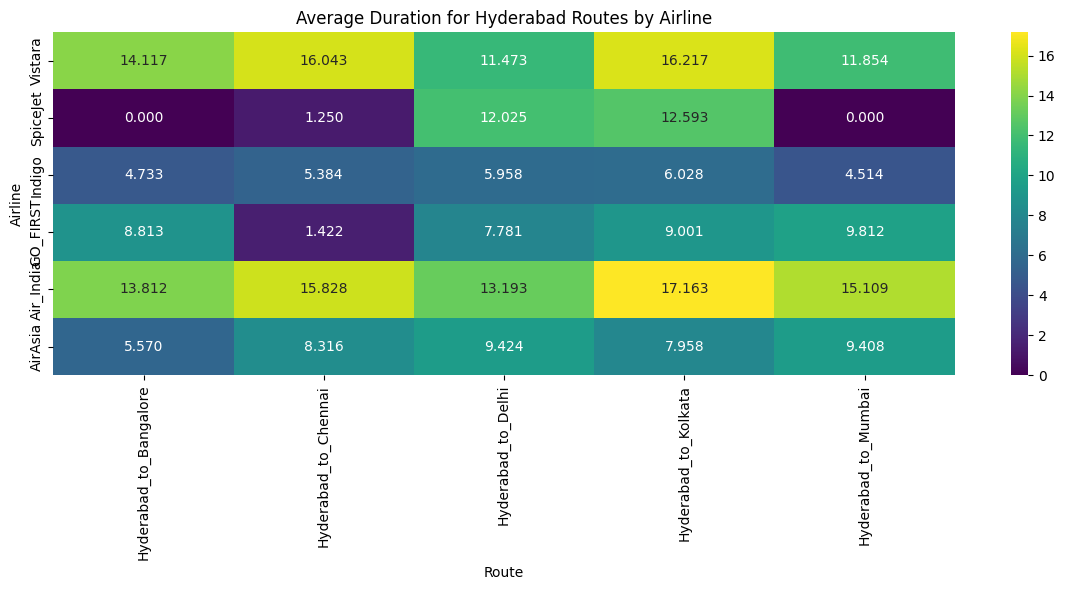

In [62]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Average Duration for Hyderabad Routes by Airline")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

In [63]:
df = duckdb.sql("""
SELECT airline, source_city || '_to_' || destination_city AS Round_Trips, COUNT(*) AS trip_count
FROM test 
WHERE source_city || '_to_' || destination_city IS NOT NULL
GROUP BY airline, source_city, destination_city
ORDER BY airline DESC;
""").df()

print(df)

     airline             Round_Trips  trip_count
0    Vistara      Bangalore_to_Delhi        5423
1    Vistara     Bangalore_to_Mumbai        5380
2    Vistara      Hyderabad_to_Delhi        3632
3    Vistara     Hyderabad_to_Mumbai        4451
4    Vistara      Delhi_to_Bangalore        5379
..       ...                     ...         ...
172  AirAsia  Bangalore_to_Hyderabad         192
173  AirAsia    Bangalore_to_Chennai         138
174  AirAsia    Hyderabad_to_Chennai         148
175  AirAsia      Bangalore_to_Delhi        1558
176  AirAsia     Bangalore_to_Mumbai         628

[177 rows x 3 columns]


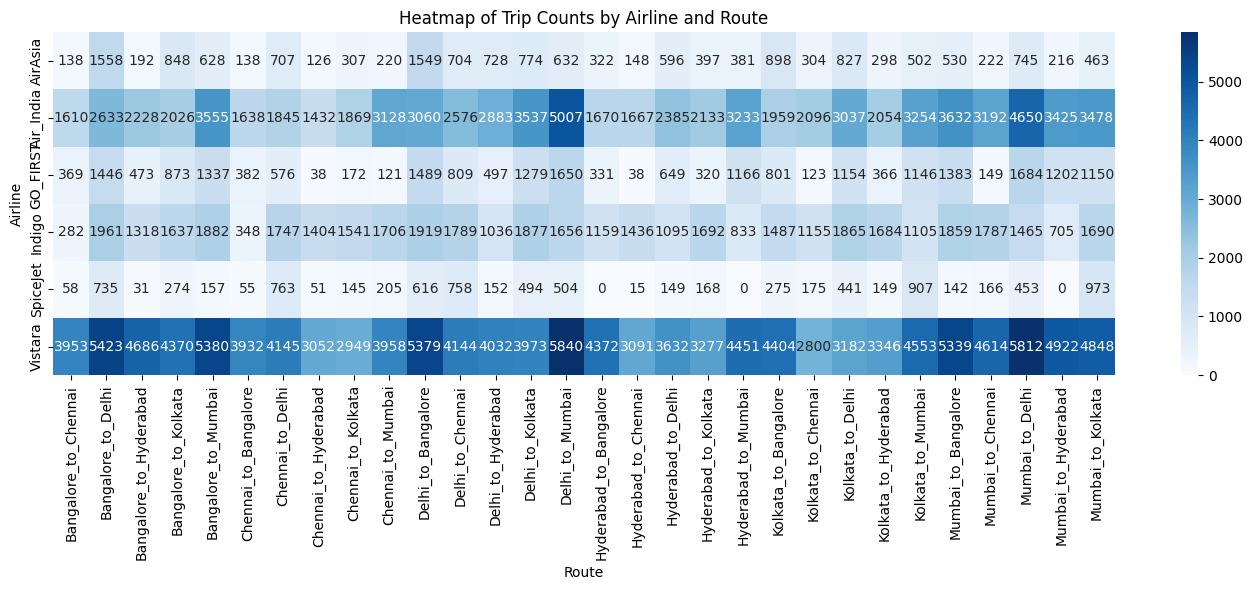

In [64]:
# Pivot for heatmap
pivot = df.pivot(index="airline", columns="Round_Trips", values="trip_count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".0f")

plt.title("Heatmap of Trip Counts by Airline and Route")
plt.xlabel("Route")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

In [65]:
pivot = df.pivot(
    index="airline",
    columns="Round_Trips",
    values="trip_count"
).fillna(0)

pivot.head()


Round_Trips,Bangalore_to_Chennai,Bangalore_to_Delhi,Bangalore_to_Hyderabad,Bangalore_to_Kolkata,Bangalore_to_Mumbai,Chennai_to_Bangalore,Chennai_to_Delhi,Chennai_to_Hyderabad,Chennai_to_Kolkata,Chennai_to_Mumbai,...,Kolkata_to_Bangalore,Kolkata_to_Chennai,Kolkata_to_Delhi,Kolkata_to_Hyderabad,Kolkata_to_Mumbai,Mumbai_to_Bangalore,Mumbai_to_Chennai,Mumbai_to_Delhi,Mumbai_to_Hyderabad,Mumbai_to_Kolkata
airline,,,,,,,,,,,,,,,,,,,,,
AirAsia,138.0,1558.0,192.0,848.0,628.0,138.0,707.0,126.0,307.0,220.0,...,898.0,304.0,827.0,298.0,502.0,530.0,222.0,745.0,216.0,463.0
Air_India,1610.0,2633.0,2228.0,2026.0,3555.0,1638.0,1845.0,1432.0,1869.0,3128.0,...,1959.0,2096.0,3037.0,2054.0,3254.0,3632.0,3192.0,4650.0,3425.0,3478.0
GO_FIRST,369.0,1446.0,473.0,873.0,1337.0,382.0,576.0,38.0,172.0,121.0,...,801.0,123.0,1154.0,366.0,1146.0,1383.0,149.0,1684.0,1202.0,1150.0
Indigo,282.0,1961.0,1318.0,1637.0,1882.0,348.0,1747.0,1404.0,1541.0,1706.0,...,1487.0,1155.0,1865.0,1684.0,1105.0,1859.0,1787.0,1465.0,705.0,1690.0
SpiceJet,58.0,735.0,31.0,274.0,157.0,55.0,763.0,51.0,145.0,205.0,...,275.0,175.0,441.0,149.0,907.0,142.0,166.0,453.0,0.0,973.0


In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pivot_norm = pd.DataFrame(
    scaler.fit_transform(pivot),
    index=pivot.index,
    columns=pivot.columns
)


In [67]:
df_long = pivot.reset_index().melt(
    id_vars="airline",
    var_name="Round_Trips",
    value_name="trip_count"
)


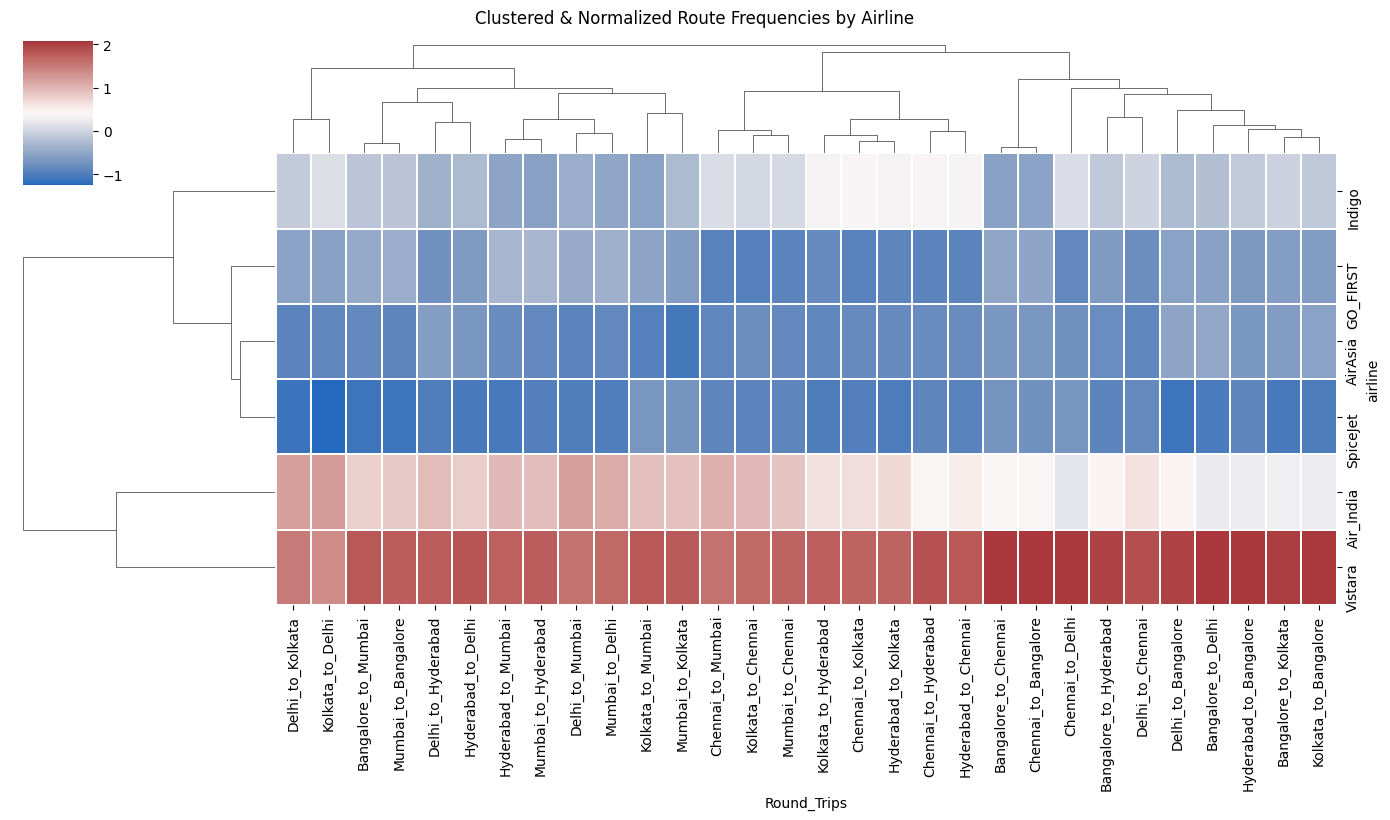

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    pivot_norm,
    cmap="vlag",
    linewidths=0.3,
    figsize=(14, 8)
)

plt.suptitle("Clustered & Normalized Route Frequencies by Airline", y=1.02)
plt.show()


## Discovery #12: PIVOT - days_left

In [69]:
df = duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (1,2,3,4,5,6,7,8,9))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").df()

print(df)

     airline         1         2         3         4         5         6  \
0    Vistara  28188.20  39808.80  38911.83  35310.99  34793.90  33091.39   
1   SpiceJet  13136.91  11362.18   9745.27   7961.19   7656.86   7455.42   
2     Indigo  13816.15  12166.58  11730.41   8754.83   8518.11   8376.47   
3   GO_FIRST  11512.71  12028.42  10681.79   7913.30   7348.61   7163.32   
4  Air_India  22995.68  33291.21  31648.96  26415.20  26999.79  26438.81   
5    AirAsia  10867.71   9374.68   8732.80   7198.10   8300.84   7965.73   

          7         8         9  
0  33770.92  33095.28  33392.42  
1   7717.96   8177.95   8351.11  
2   8467.25   8363.21   9041.66  
3   7871.30   7525.71   8764.19  
4  27335.65  26297.38  27805.68  
5   8157.47   8653.07   9036.85  


In [70]:
pivot = df.set_index("airline")
pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
pivot.head()


,1,2,3,4,5,6,7,8,9
airline,,,,,,,,,
Vistara,28188.20,39808.80,38911.83,35310.99,34793.90,33091.39,33770.92,33095.28,33392.42
SpiceJet,13136.91,11362.18,9745.27,7961.19,7656.86,7455.42,7717.96,8177.95,8351.11
Indigo,13816.15,12166.58,11730.41,8754.83,8518.11,8376.47,8467.25,8363.21,9041.66
GO_FIRST,11512.71,12028.42,10681.79,7913.30,7348.61,7163.32,7871.30,7525.71,8764.19
Air_India,22995.68,33291.21,31648.96,26415.20,26999.79,26438.81,27335.65,26297.38,27805.68


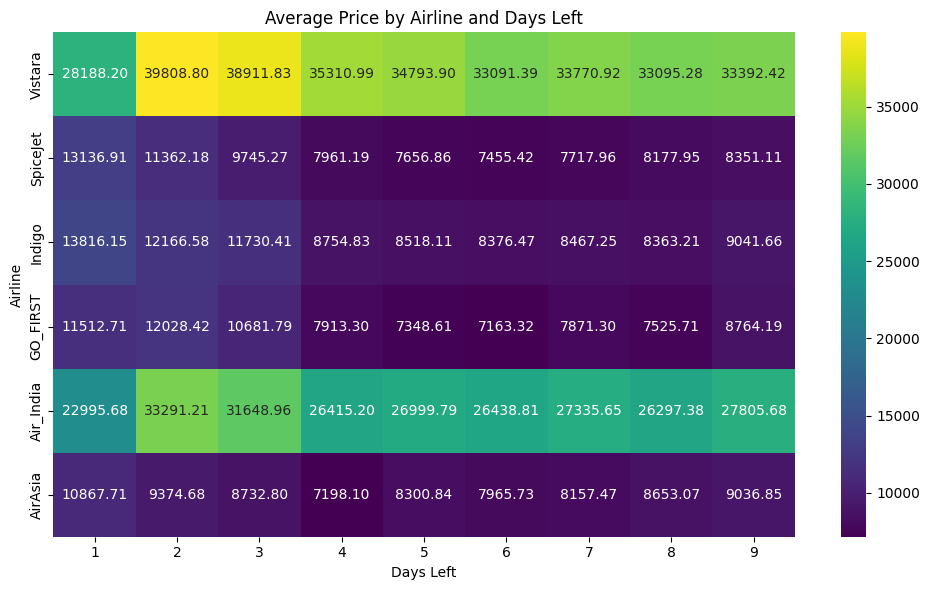

In [71]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".2f")

plt.title("Average Price by Airline and Days Left")
plt.xlabel("Days Left")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


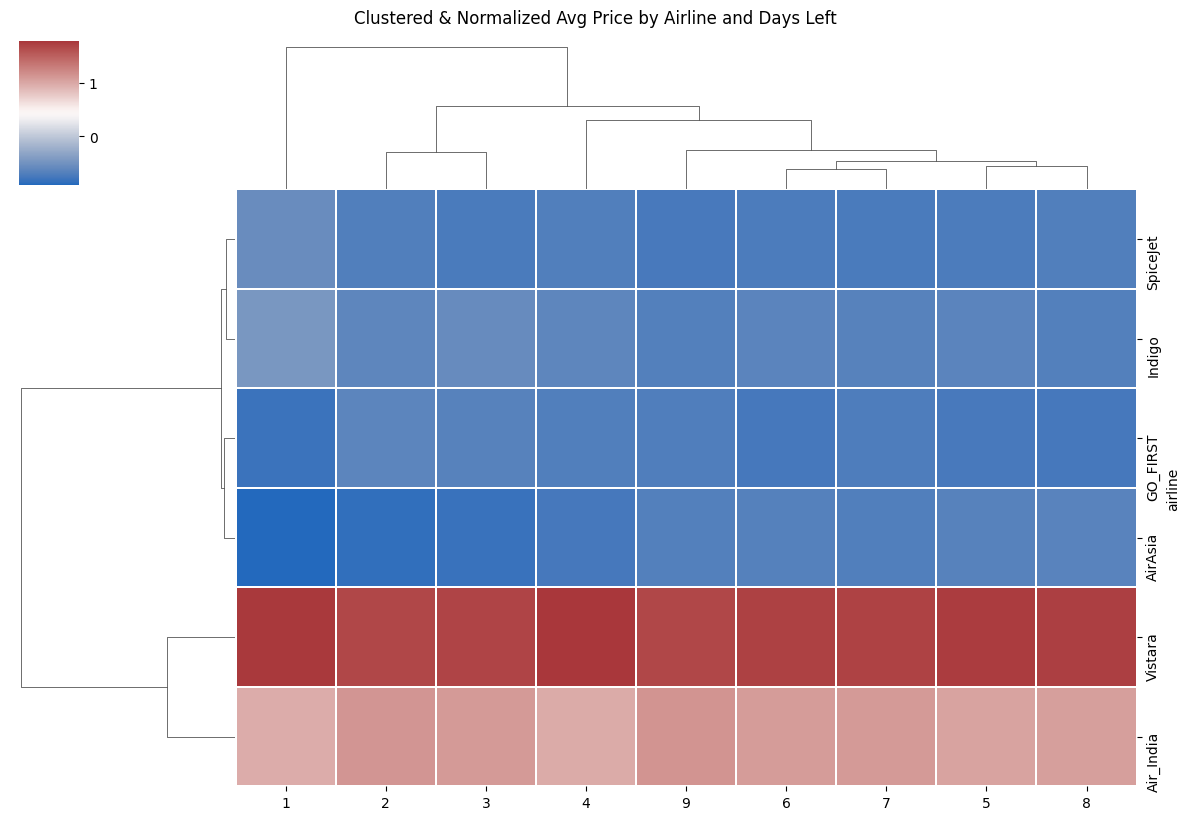

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pivot_norm = pd.DataFrame(
    scaler.fit_transform(pivot),
    index=pivot.index,
    columns=pivot.columns
)

sns.clustermap(
    pivot_norm,
    cmap="vlag",
    linewidths=0.3,
    figsize=(12, 8)
)

plt.suptitle("Clustered & Normalized Avg Price by Airline and Days Left", y=1.02)
plt.show()


In [73]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (10, 11, 12,13,14,15,16,17,18,19))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").df()

,airline,10,11,12,13,14,15,16,17,18,19
0,Vistara,34163.09,32406.47,31902.60,31972.40,31968.83,31165.18,30046.25,30114.70,29548.23,29161.59
1,SpiceJet,8162.17,7322.20,7095.18,7168.61,7329.97,5864.86,5166.80,5378.34,4772.44,5223.51
2,Indigo,8839.14,7837.74,7341.83,7544.80,7714.41,7138.00,5540.82,5538.95,4769.06,4562.93
3,GO_FIRST,9371.48,6951.49,7071.68,6968.23,7054.66,6340.59,5387.78,5368.17,5032.39,5171.88
4,Air_India,27162.79,26232.58,26295.41,25874.88,26292.87,25497.94,24049.46,23254.91,22842.46,22089.97
5,AirAsia,10112.17,6814.23,6449.64,6523.45,6703.00,5871.24,4453.19,4302.63,3496.49,3509.04


In [74]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (20, 21, 22, 23, 24, 25, 26, 27, 28, 29))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").df()

,airline,20,21,22,23,24,25,26,27,28,29
0,Vistara,29257.90,28961.52,29308.52,29571.91,29775.07,29173.11,29034.07,29986.38,29344.56,29530.21
1,SpiceJet,4994.43,5043.35,4916.78,5207.49,5244.17,4893.25,4806.97,4866.71,4897.44,4872.03
2,Indigo,4600.94,4573.16,4615.14,4960.98,4851.61,4400.01,4277.60,4378.69,4400.77,4466.41
3,GO_FIRST,5121.82,5089.51,5095.76,5140.77,5095.42,5048.06,5061.24,5114.00,5134.94,5092.37
4,Air_India,22618.77,22330.24,22101.39,22419.08,22482.48,22223.55,21550.21,22742.67,22062.01,22316.10
5,AirAsia,3250.77,3020.78,3196.46,3191.64,3284.53,2918.41,2848.20,2914.65,2949.96,3004.12


In [75]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (30, 31, 32, 33, 34, 35, 36, 37, 38, 39))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").df()

,airline,30,31,32,33,34,35,36,37,38,39
0,Vistara,29404.09,29413.22,28799.48,29227.23,29292.23,28665.13,29083.45,29254.96,29426.35,28756.69
1,SpiceJet,5442.39,5372.11,5319.04,5447.17,5544.23,5735.38,5485.18,5656.71,5902.12,5644.81
2,Indigo,4496.20,3685.37,3280.13,3291.33,3587.01,4477.72,4554.99,4393.56,4833.97,3418.73
3,GO_FIRST,5132.94,5205.89,5058.46,5156.46,5191.46,5250.40,5170.53,5094.02,5537.78,5124.47
4,Air_India,22041.37,21939.84,22053.11,21661.95,22541.36,21465.88,21600.45,21735.07,22167.97,21938.86
5,AirAsia,3085.94,3116.61,2888.84,2941.69,3236.10,3518.17,3326.69,3084.03,3703.69,3048.70


In [76]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (40, 41, 42, 43, 44, 45, 46, 47, 48, 49))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").df()

,airline,40,41,42,43,44,45,46,47,48,49
0,Vistara,28851.12,29122.10,28882.90,29212.24,28857.92,28734.08,29047.20,28405.03,28801.06,28721.39
1,SpiceJet,5578.93,5554.58,5550.70,5556.29,5598.99,5438.47,5339.34,5292.32,5350.40,5479.38
2,Indigo,3250.80,3276.57,3195.76,3450.53,3514.15,3554.13,3195.21,3153.01,3305.00,3264.93
3,GO_FIRST,5066.01,5090.40,5103.03,5140.26,5123.28,5276.34,5096.14,5030.80,5103.00,5117.14
4,Air_India,21699.55,21802.21,21613.78,21602.97,21543.88,22112.08,21529.83,20375.58,20889.79,21018.53
5,AirAsia,2878.56,2860.68,2915.09,3044.29,3052.29,3083.74,2847.26,2827.71,2836.82,2854.61


## Discovery #11: PIVOT - Departure Time 

In [77]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Early_Morning')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Early_Morning_to_Afternoon,Early_Morning_to_Early_Morning,Early_Morning_to_Evening,Early_Morning_to_Late_Night,Early_Morning_to_Morning,Early_Morning_to_Night
0,Vistara,29351.49,18155.09,32171.75,53920.73,19989.15,32706.51
1,SpiceJet,6545.43,4898.20,8180.44,7176.21,5085.64,6512.75
2,Indigo,5757.89,3304.22,6562.26,NaN,4674.66,7050.86
3,GO_FIRST,5648.29,3840.81,6054.38,NaN,4609.83,6402.15
4,Air_India,22878.12,16246.64,25799.58,31489.70,17040.95,25259.96
5,AirAsia,4464.18,3726.14,4936.41,7254.45,4222.45,4362.24


In [78]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Morning')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Morning_to_Afternoon,Morning_to_Early_Morning,Morning_to_Evening,Morning_to_Late_Night,Morning_to_Morning,Morning_to_Night
0,Vistara,23006.13,26680.43,31393.97,34262.63,23642.48,33517.47
1,SpiceJet,6502.62,5555.89,7814.88,5562.44,6336.52,6772.11
2,Indigo,5514.24,NaN,6409.15,NaN,3715.93,7053.17
3,GO_FIRST,6115.52,NaN,7087.61,5752.13,3777.54,6335.60
4,Air_India,19273.53,17263.87,23521.17,33219.21,17685.53,23711.01
5,AirAsia,4592.79,NaN,4403.59,3460.11,2659.63,3835.57


In [79]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Afternoon')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Afternoon_to_Afternoon,Afternoon_to_Early_Morning,Afternoon_to_Evening,Afternoon_to_Late_Night,Afternoon_to_Morning,Afternoon_to_Night
0,Vistara,21047.75,26240.16,25264.20,29774.82,29567.14,31434.69
1,SpiceJet,8838.43,6526.57,7229.80,9002.13,7295.69,7771.81
2,Indigo,3706.14,NaN,5744.00,5971.24,NaN,5833.88
3,GO_FIRST,3140.71,6697.16,4598.25,5503.16,7397.23,5959.92
4,Air_India,20835.59,21591.21,20899.12,25520.07,24479.11,26375.30
5,AirAsia,2616.30,NaN,4393.97,3866.74,NaN,5032.92


In [80]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Evening')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Evening_to_Afternoon,Evening_to_Early_Morning,Evening_to_Evening,Evening_to_Late_Night,Evening_to_Morning,Evening_to_Night
0,Vistara,27319.87,33422.51,32095.33,27554.23,34666.10,25700.99
1,SpiceJet,6373.27,5710.08,6916.49,6288.27,6118.08,5086.13
2,Indigo,NaN,5790.09,4010.07,5381.57,9153.00,4775.95
3,GO_FIRST,NaN,6012.37,2886.27,5611.53,6611.06,5096.94
4,Air_India,25469.06,21124.62,22949.36,22874.10,24764.21,21147.33
5,AirAsia,4328.98,4145.54,3669.00,3903.68,4457.23,3999.97


In [81]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Night')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Night_to_Afternoon,Night_to_Early_Morning,Night_to_Evening,Night_to_Late_Night,Night_to_Morning,Night_to_Night
0,Vistara,33364.99,29418.72,33000.17,16983.95,32690.77,23809.03
1,SpiceJet,6025.58,6196.52,5623.50,5269.69,5926.31,5309.60
2,Indigo,NaN,4456.24,NaN,4211.58,5566.30,3567.60
3,GO_FIRST,5537.58,5639.96,NaN,3675.08,4975.02,3389.19
4,Air_India,27871.78,18251.42,28277.85,22956.79,28091.38,20744.67
5,AirAsia,3547.67,3083.00,NaN,3543.24,3362.15,3144.53


In [82]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Late_Night')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").df()

,airline,Late_Night_to_Afternoon,Late_Night_to_Early_Morning,Late_Night_to_Evening,Late_Night_to_Late_Night,Late_Night_to_Morning,Late_Night_to_Night
0,Indigo,6222.8,3680.56,NaN,3801.60,4796.38,NaN
1,GO_FIRST,NaN,4093.67,7154.88,NaN,NaN,NaN
2,Air_India,23161.4,14494.17,29185.70,NaN,30120.19,29439.81
3,AirAsia,NaN,3674.03,NaN,5190.71,NaN,NaN


# Machine Learning Modal

In [83]:
df = Clean_Dataset_df.copy()

In [84]:
df = df.dropna(subset=["price"])

In [85]:
X = df.drop("price", axis=1)
y = df["price"]

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [88]:
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'flight_length'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['duration', 'days_left'], dtype='object'))])),
                ('rf',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [89]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)


MAE: 856.3299877181342
R²: 0.9891153516702941
